In [ ]:
!pip install py3Dmol biopython -q

In [ ]:
import py3Dmol

view = py3Dmol.view(query="pdb:1TSR", width=800, height=600)
view.setStyle({}, {})
view.setStyle({"chain": "B"}, {"cartoon": {"color": "lightgray"}})
view.setStyle({"chain": ["E", "F"]}, {"stick": {"colorscheme": "orangeCarbon"}})

view.addStyle({"chain": "B", "resi": [248, 273]}, {"stick": {"colorscheme": "blueCarbon"}})           # contact hotspots
view.addStyle({"chain": "B", "resi": [175, 245, 282, 220]}, {"stick": {"colorscheme": "redCarbon"}})  # structural hotspots
view.addStyle({"chain": "B", "resi": [176, 179, 238, 242]}, {"stick": {"colorscheme": "purpleCarbon"}}) # zinc holders
view.addStyle({"chain": "B", "elem": "Zn"}, {"sphere": {"color": "gray", "scale": 0.8}})

view.zoomTo({"chain": "B"})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
from google.colab import files
files.upload()   # a button appears: pick tp53_missense_clean.csv

Saving tp53_missense_clean.csv to tp53_missense_clean (1).csv


{'tp53_missense_clean (1).csv': b'cancer_type,sample,protein_change,mutation_type,residue\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4938-01,R248W,Missense_Mutation,248\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4942-01,C275F,Missense_Mutation,275\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-4943-01,Y220C,Missense_Mutation,220\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-5393-01,P250L,Missense_Mutation,250\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-5396-01,R273H,Missense_Mutation,273\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-6290-01,H179R,Missense_Mutation,179\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-6666-01,T155P,Missense_Mutation,155\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-6666-01,R175H,Missense_Mutation,175\n"Brain Lower Grade Glioma (TCGA, PanCancer Atlas)",TCGA-CS-6667-01,H214R,Missense_Mutation,214\n"Brain Lower Grade Glioma (TCGA, PanCancer At

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Bio.PDB import PDBList, PDBParser
from Bio.PDB.SASA import ShrakeRupley

# Mutation data from notebook 1
missense = pd.read_csv("tp53_missense_clean.csv")
counts = missense["residue"].value_counts().rename_axis("residue").reset_index(name="n_tumours")

# Download and read the 3D structure
path = PDBList().retrieve_pdb_file("1TSR", file_format="pdb", pdir=".")
model = PDBParser(QUIET=True).get_structure("1TSR", path)[0]

DNA_CHAINS = ["E", "F"]

# Coordinates of every DNA atom (skipping water)
dna_coords = np.array([atom.coord
                       for ch in DNA_CHAINS
                       for res in model[ch] if res.id[0] == " "
                       for atom in res])

def min_dist_to_dna(res):
    """Shortest distance (in Ångströms) from any atom in this residue to any DNA atom."""
    coords = np.array([atom.coord for atom in res])
    return np.min(np.linalg.norm(coords[:, None, :] - dna_coords[None, :, :], axis=2))

print("Loaded", len(counts), "mutated residues and", len(dna_coords), "DNA atoms")

Loaded 173 mutated residues and 855 DNA atoms


In [ ]:
for ch in ["A", "B", "C"]:
    n_close = sum(1 for res in model[ch] if res.id[0] == " " and min_dist_to_dna(res) < 4)
    print(f"Chain {ch}: {n_close} residues within 4 Å of DNA")

Chain A: 4 residues within 4 Å of DNA
Chain B: 12 residues within 4 Å of DNA
Chain C: 4 residues within 4 Å of DNA


In [ ]:
CHAIN = "B"
chain = model[CHAIN]

# Remove non-protein bits (zinc, water) so burial is calculated on protein only
for res in list(chain):
    if res.id[0] != " ":
        chain.detach_child(res.id)

# Solvent accessibility: how exposed each residue is to water
ShrakeRupley().compute(chain, level="R")

# Maximum possible exposure for each amino acid (Tien et al., 2013)
MAX_ASA = {"ALA":129,"ARG":274,"ASN":195,"ASP":193,"CYS":167,"GLN":225,"GLU":223,"GLY":104,
           "HIS":224,"ILE":197,"LEU":201,"LYS":236,"MET":224,"PHE":240,"PRO":159,"SER":155,
           "THR":172,"TRP":285,"TYR":263,"VAL":174}

rows = []
for res in chain:
    rows.append({
        "residue": res.id[1],
        "amino_acid": res.get_resname(),
        "dist_to_dna": round(min_dist_to_dna(res), 2),
        "rel_exposure": round(res.sasa / MAX_ASA[res.get_resname()], 2)
    })

structure_df = pd.DataFrame(rows)

# Combine with mutation counts (residues never mutated get 0)
merged = structure_df.merge(counts, on="residue", how="left").fillna({"n_tumours": 0})
merged["n_tumours"] = merged["n_tumours"].astype(int)

merged.to_csv("tp53_structure_mutations.csv", index=False)
merged.sort_values("n_tumours", ascending=False).head(10)

,residue,amino_acid,dist_to_dna,rel_exposure,n_tumours
177,273,ARG,2.530000,0.30,267
152,248,ARG,3.380000,0.62,224
79,175,ARG,13.160000,0.07,167
149,245,GLY,9.690000,0.05,91
186,282,ARG,9.840000,0.12,89
124,220,TYR,29.820000,0.09,75
83,179,HIS,8.160000,0.24,69
97,193,HIS,16.110001,0.02,64
62,158,ARG,23.959999,0.12,50
80,176,CYS,10.790000,0.02,50


In [ ]:
def zone(row):
    if row["dist_to_dna"] <= 5:
        return "DNA contact"
    elif row["rel_exposure"] < 0.2:
        return "Buried core"
    else:
        return "Exposed surface"

merged["zone"] = merged.apply(zone, axis=1)

summary = merged.groupby("zone").agg(residues=("residue", "count"), mutations=("n_tumours", "sum"))
summary["% of residues"] = (100 * summary["residues"] / summary["residues"].sum()).round(1)
summary["% of mutations"] = (100 * summary["mutations"] / summary["mutations"].sum()).round(1)
summary

,residues,mutations,% of residues,% of mutations
zone,,,,
Buried core,83,1604,42.8,60.7
DNA contact,18,706,9.3,26.7
Exposed surface,93,332,47.9,12.6


In [ ]:
from scipy.stats import mannwhitneyu

hot = merged[merged["n_tumours"] >= 20]
rest = merged[merged["n_tumours"] < 20]

print(f"{len(hot)} hotspot residues (20+ tumours) vs {len(rest)} other residues\n")

for col, label in [("dist_to_dna", "Distance to DNA (Å)"), ("rel_exposure", "Relative exposure")]:
    stat, p = mannwhitneyu(hot[col], rest[col])
    print(f"{label}: hotspots median {hot[col].median():.2f}, others median {rest[col].median():.2f}, p = {p:.4f}")

37 hotspot residues (20+ tumours) vs 157 other residues

Distance to DNA (Å): hotspots median 10.13, others median 19.05, p = 0.0001
Relative exposure: hotspots median 0.06, others median 0.28, p = 0.0000


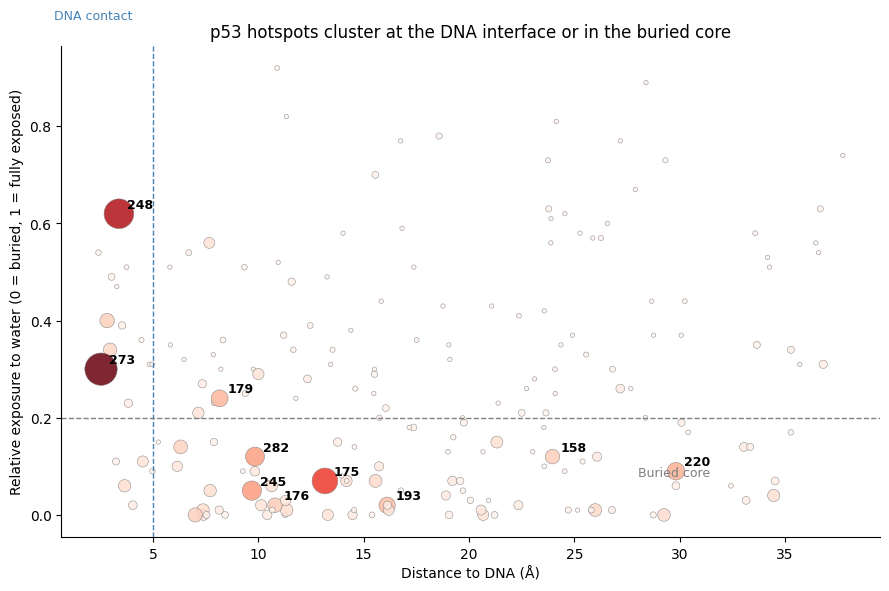

In [ ]:
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(merged["dist_to_dna"], merged["rel_exposure"],
           s=10 + merged["n_tumours"] * 2, c=merged["n_tumours"], cmap="Reds",
           edgecolors="gray", linewidths=0.4, alpha=0.85)

for _, r in merged.sort_values("n_tumours", ascending=False).head(10).iterrows():
    ax.annotate(int(r["residue"]), (r["dist_to_dna"], r["rel_exposure"]),
                textcoords="offset points", xytext=(6, 4), fontsize=9, fontweight="bold")

ax.axvline(5, color="steelblue", linestyle="--", linewidth=1)
ax.axhline(0.2, color="gray", linestyle="--", linewidth=1)
ax.text(0.3, 1.02, "DNA contact", color="steelblue", fontsize=9)
ax.text(28, 0.08, "Buried core", color="gray", fontsize=9)

ax.set_xlabel("Distance to DNA (Å)")
ax.set_ylabel("Relative exposure to water (0 = buried, 1 = fully exposed)")
ax.set_title("p53 hotspots cluster at the DNA interface or in the buried core")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("fig2_distance_vs_burial.png", dpi=200)
plt.show()

In [ ]:
import matplotlib.colors as mcolors

norm = mcolors.LogNorm(vmin=1, vmax=merged["n_tumours"].max())
cmap = plt.get_cmap("Reds")

view = py3Dmol.view(query="pdb:1TSR", width=800, height=600)
view.setStyle({}, {})
view.setStyle({"chain": CHAIN}, {"cartoon": {"color": "#e8e8e8"}})
view.setStyle({"chain": DNA_CHAINS}, {"stick": {"colorscheme": "lightblueCarbon"}})

for _, r in merged[merged["n_tumours"] > 0].iterrows():
    color = mcolors.to_hex(cmap(norm(r["n_tumours"])))
    view.addStyle({"chain": CHAIN, "resi": int(r["residue"])}, {"cartoon": {"color": color}})

view.zoomTo({"chain": CHAIN})
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.